# Wine quality prediction project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import re
import matplotlib.cm as cm
from itertools import permutations

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import numpy as np

from sklearn.preprocessing import RobustScaler  

from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Things / Rules I learned and will be using

1. td ( variable name ) : temporary data frame
2. After every plot write a conclusion

In [2]:
# Define all functions here

def printf_handler(func):
    def inner(*args, **kwargs):
        if len(args) == 1 and isinstance(args[0], (list, tuple)):
            func(*args[0])

        elif len(args) > 1 and not any(isinstance(arg, (list, tuple)) for arg in args):
            func(*args)

        elif len(args) > 1 and any(isinstance(arg, (list, tuple)) for arg in args):
            processed_args = []
            for arg in args:
                if isinstance(arg, (list, tuple)):
                    processed_args.extend(arg)
                else:
                    processed_args.append(arg)
            func(*processed_args)

        else:
            func(*args)
    return inner

@printf_handler
def printf(*args):
    """Print each argument on a new line"""
    for arg in args:
        print(arg, '\n')



## Data Loading and overview


### Section 1
I later found out that reading with a different separator would solve all the problems , but since i started this .I will finish this section

In [3]:
path = kagglehub.dataset_download("sumit17125/red-wine-quality-dataset")
path = "C:/Users/fbase/.cache/kagglehub/datasets/sumit17125/red-wine-quality-dataset/versions/1"
df = pd.read_csv(path + "/winequality-red.csv")


In [8]:
df

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
...,...
1594,6.2;0.6;0.08;2;0.09;32;44;0.9949;3.45;0.58;10.5;5
1595,5.9;0.55;0.1;2.2;0.062;39;51;0.99512;3.52;0.76...
1596,6.3;0.51;0.13;2.3;0.076;29;40;0.99574;3.42;0.7...
1597,5.9;0.645;0.12;2;0.075;32;44;0.99547;3.57;0.71...


In [9]:
slot1 = df.shape,df.columns,len(df.columns),df.iloc[0]
printf(slot1)

(1599, 1) 

Index(['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'], dtype='str') 

1 

fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
Name: 0, dtype: str 



In [10]:
# str(df.columns) didn't do the join , so had to use join
columns = re.sub('"','',''.join(df.columns)).split(';')
print(columns)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [11]:
# Now that we have column names , we extract the row values
# What a strange behaviour
print(df.iloc[2],'\n')
print(list(df.iloc[2]))

fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
Name: 2, dtype: str 

['7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5']


In [12]:
# dunno why list() didn't work
data = np.array(df.loc[:])
data

array([['7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5'],
       ['7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5'],
       ['7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5'],
       ...,
       ['6.3;0.51;0.13;2.3;0.076;29;40;0.99574;3.42;0.75;11;6'],
       ['5.9;0.645;0.12;2;0.075;32;44;0.99547;3.57;0.71;10.2;5'],
       ['6;0.31;0.47;3.6;0.067;18;42;0.99549;3.39;0.66;11;6']],
      shape=(1599, 1), dtype=object)

In [13]:
num = df.to_numpy()

### Section 2


In [10]:
df = pd.read_csv(path + "/winequality-red.csv",sep=';')

In [15]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
columns = [i for i in df.columns]

In [17]:
printf(df.info(),df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0


In [18]:
#print(df[columns].apply(lambda x:x.unique()))     # displaying truncated input 
for col in df.columns:
    print(f"{col} uniques")
    print(df[col].unique(),'\n')

fixed acidity uniques
[ 7.4  7.8 11.2  7.9  7.3  7.5  6.7  5.6  8.9  8.5  8.1  7.6  6.9  6.3
  7.1  8.3  5.2  5.7  8.8  6.8  4.6  7.7  8.7  6.4  6.6  8.6 10.2  7.
  7.2  9.3  8.   9.7  6.2  5.   4.7  8.4 10.1  9.4  9.   8.2  6.1  5.8
  9.2 11.5  5.4  9.6 12.8 11.  11.6 12.  15.  10.8 11.1 10.  12.5 11.8
 10.9 10.3 11.4  9.9 10.4 13.3 10.6  9.8 13.4 10.7 11.9 12.4 12.2 13.8
  9.1 13.5 10.5 12.6 14.  13.7  9.5 12.7 12.3 15.6  5.3 11.3 13.   6.5
 12.9 14.3 15.5 11.7 13.2 15.9 12.1  5.1  4.9  5.9  6.   5.5] 

volatile acidity uniques
[0.7   0.88  0.76  0.28  0.66  0.6   0.65  0.58  0.5   0.615 0.61  0.62
 0.56  0.59  0.32  0.22  0.39  0.43  0.49  0.4   0.41  0.71  0.645 0.675
 0.685 0.655 0.605 0.38  1.13  0.45  0.67  0.52  0.935 0.29  0.31  0.51
 0.42  0.63  0.69  0.735 0.725 0.705 0.785 0.75  0.625 0.3   0.55  1.02
 0.775 0.9   0.545 0.575 0.33  0.54  1.07  0.695 1.33  0.745 1.04  0.715
 0.415 0.34  0.68  0.95  0.53  0.64  0.885 0.805 0.73  0.37  0.835 1.09
 0.57  0.44  0.635 0.82  0.48 


**Nothing to clean**

## EDA

In [19]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


C:\Users\fbase\AppData\Local\Temp\ipykernel_16192\4151587269.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('cool',11)


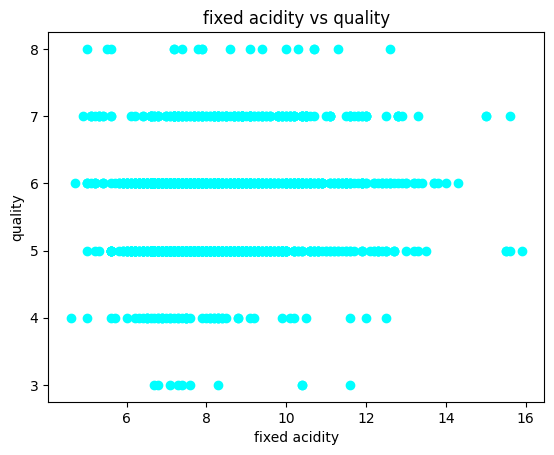

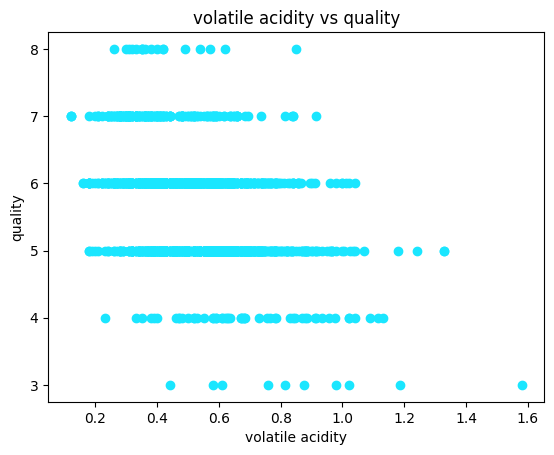

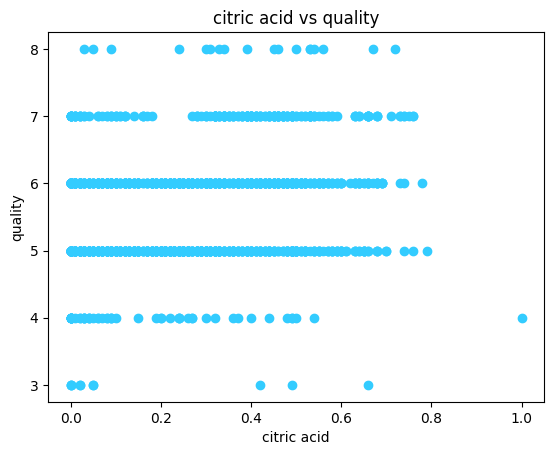

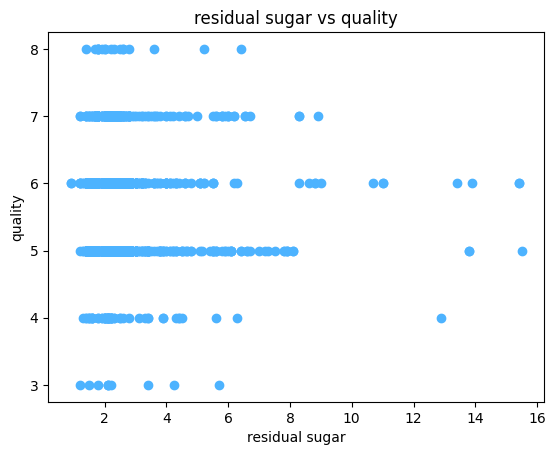

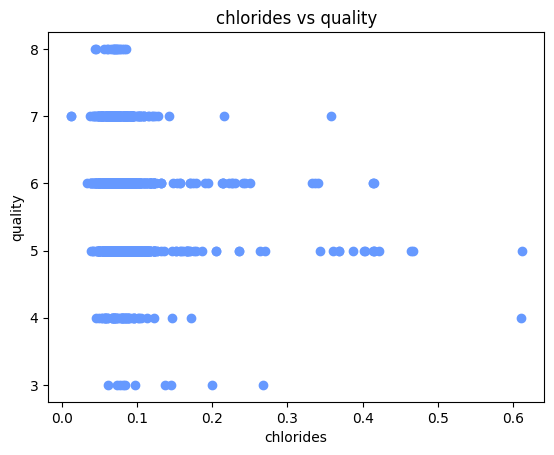

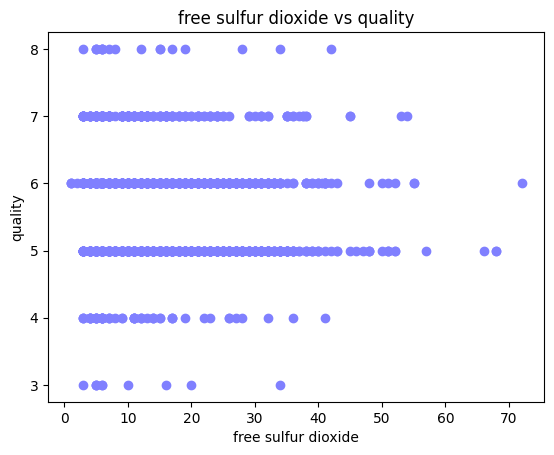

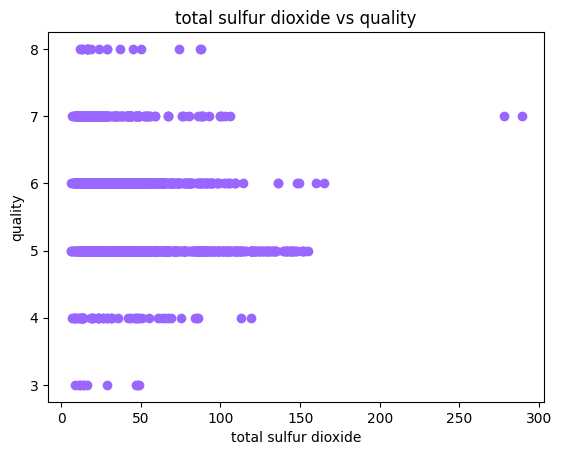

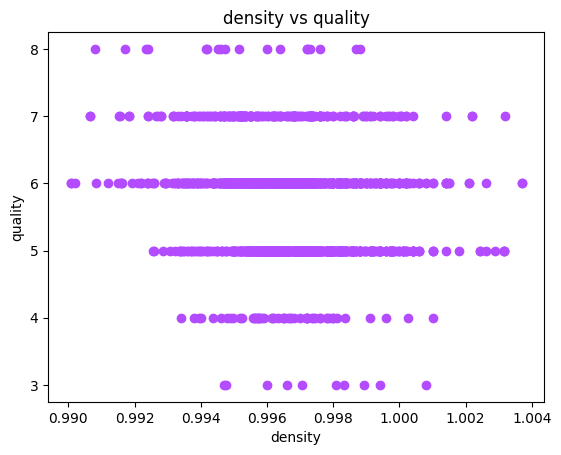

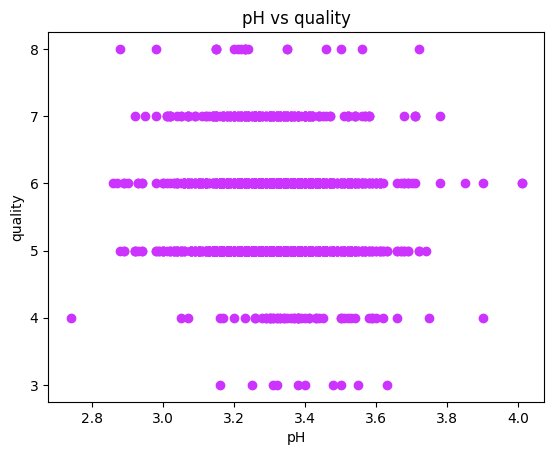

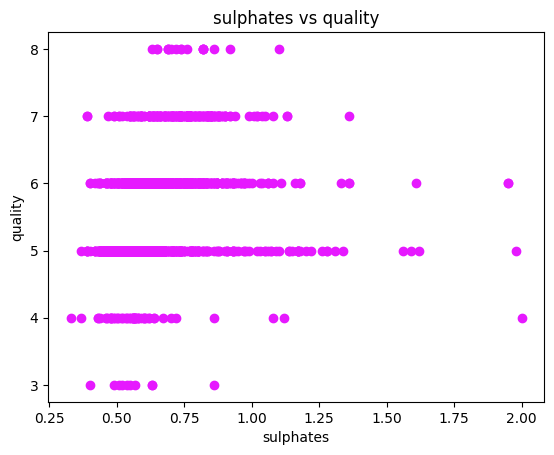

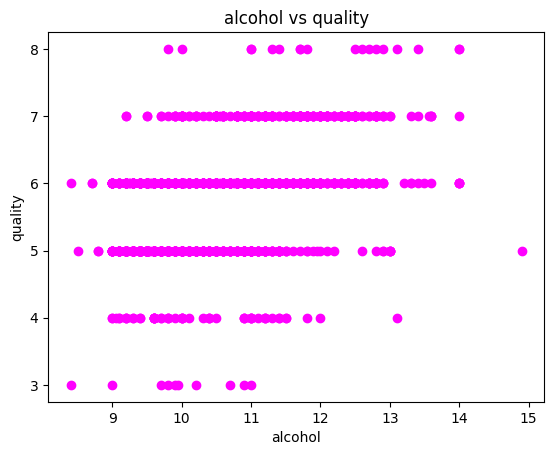

In [20]:
cmap=cm.get_cmap('cool',11)
plt.figure()
for i in range(11):
    fig = plt.axes()
    fig.scatter(df.iloc[:,i],df['quality'],marker='o',color=cmap(i))
    plt.xlabel(columns[i])
    plt.ylabel('quality')
    plt.title(f"{columns[i]} vs quality")
    plt.show()


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [22]:
df.iloc[:,i]



0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
1594    10.5
1595    11.2
1596    11.0
1597    10.2
1598    11.0
Name: alcohol, Length: 1599, dtype: float64

In [23]:
df['quality']

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

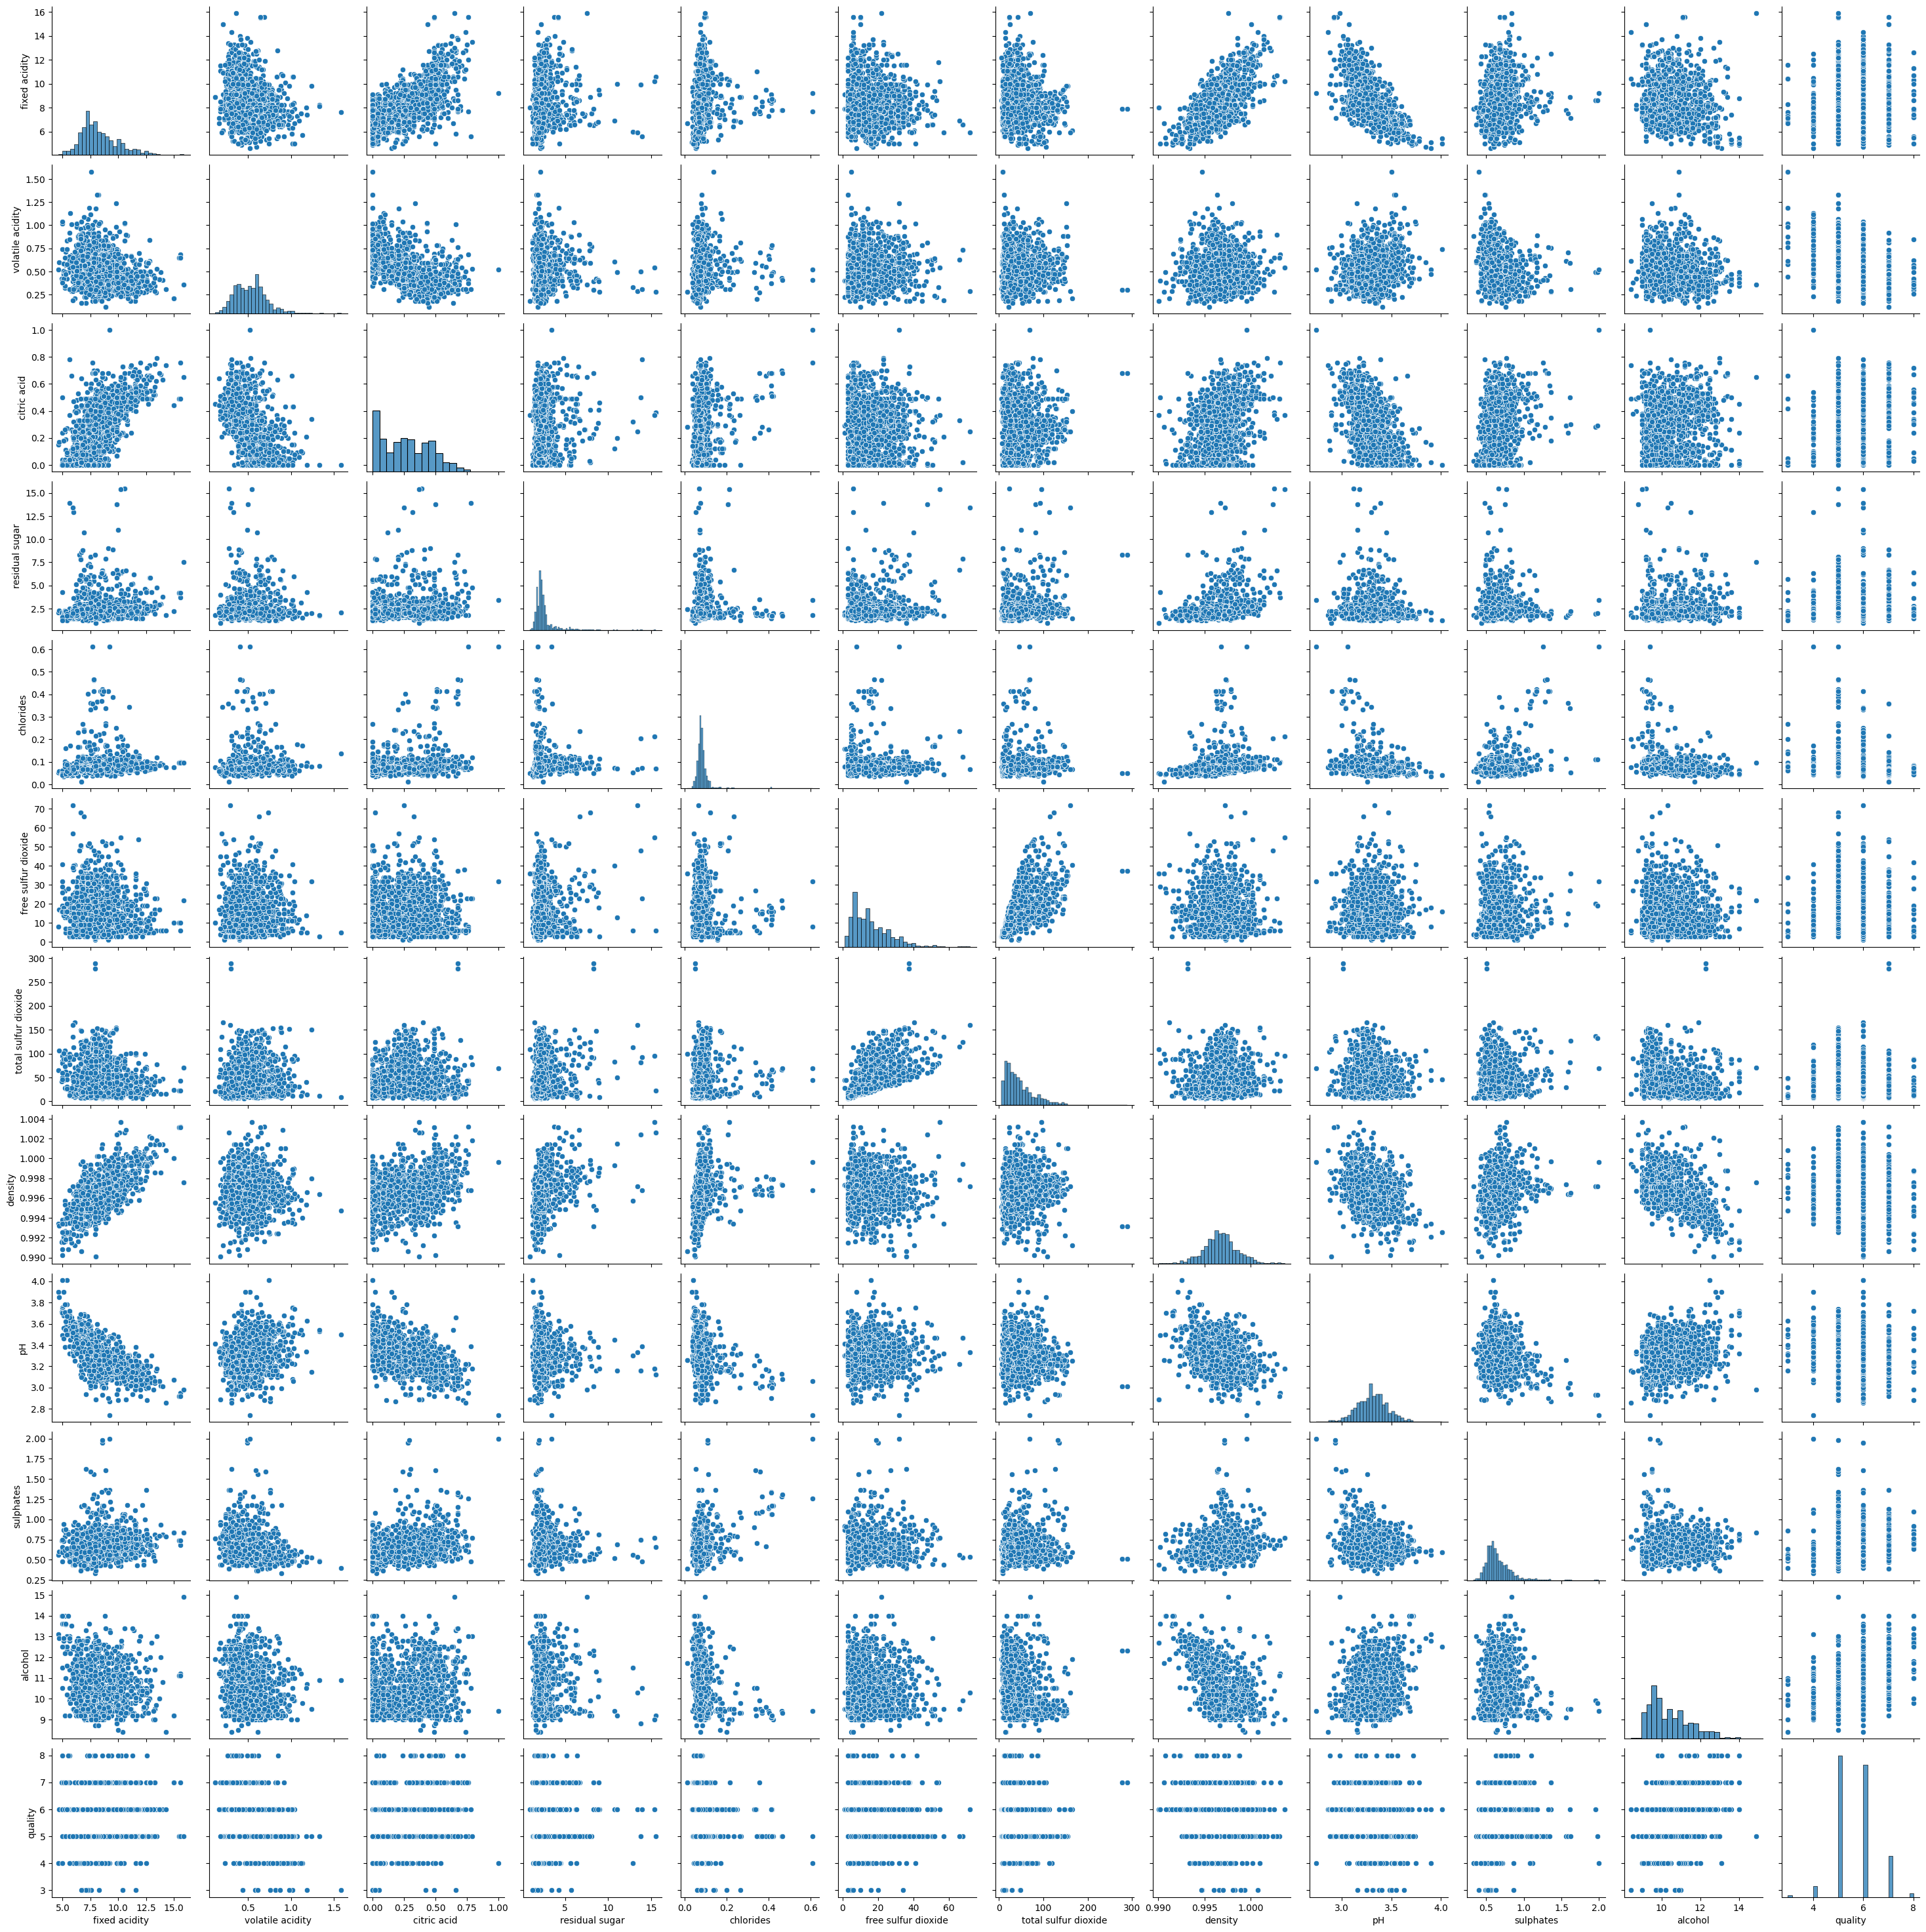

In [24]:
sns.pairplot(df)

In [25]:
for i in df:
    print(i)
    print(np.min(df[i]),np.max(df[i]),'\n')

fixed acidity
4.6 15.9 

volatile acidity
0.12 1.58 

citric acid
0.0 1.0 

residual sugar
0.9 15.5 

chlorides
0.012 0.611 

free sulfur dioxide
1.0 72.0 

total sulfur dioxide
6.0 289.0 

density
0.99007 1.00369 

pH
2.74 4.01 

sulphates
0.33 2.0 

alcohol
8.4 14.9 

quality
3 8 



<Axes: >

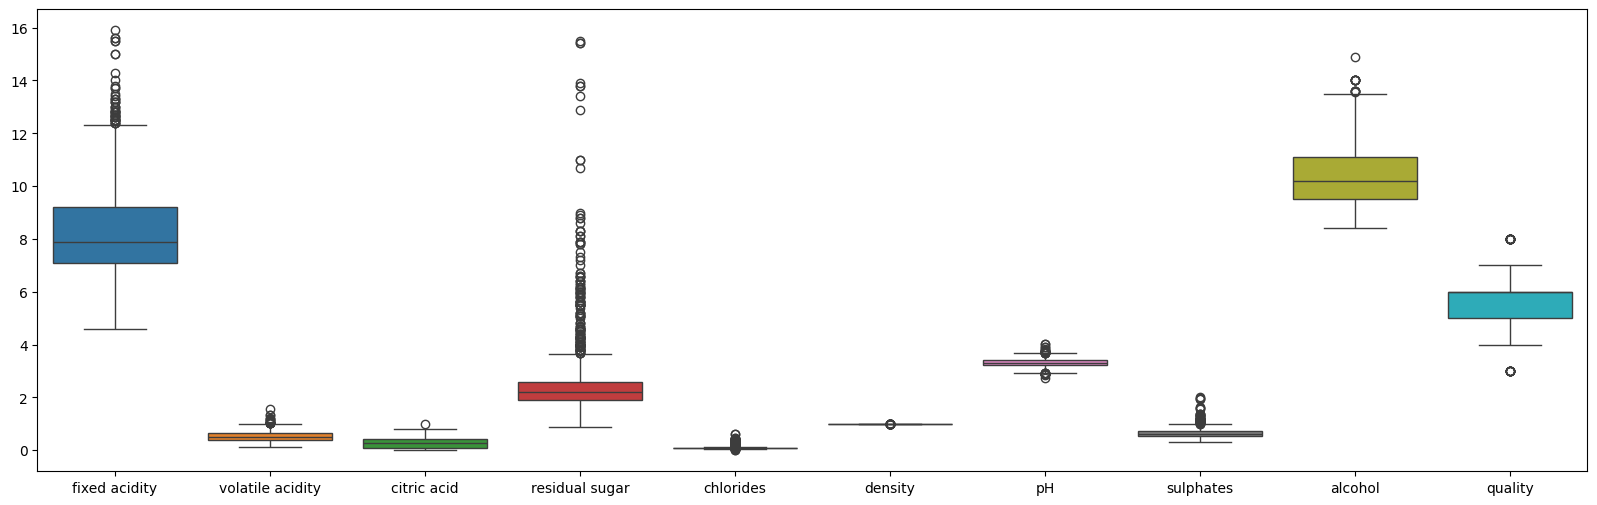

In [26]:
df1 = df.drop(['free sulfur dioxide','total sulfur dioxide'],axis=1)
plt.figure(figsize=(20,6))
sns.boxplot(data=df1)
# hmm doesn't tell much 

So the full workflow is basically:

1️⃣ Decide grid size
2️⃣ Create many subplot axes automatically
3️⃣ Loop through columns
4️⃣ Draw each boxplot on a different axis
5️⃣ Remove unused plots
6️⃣ Adjust spacing

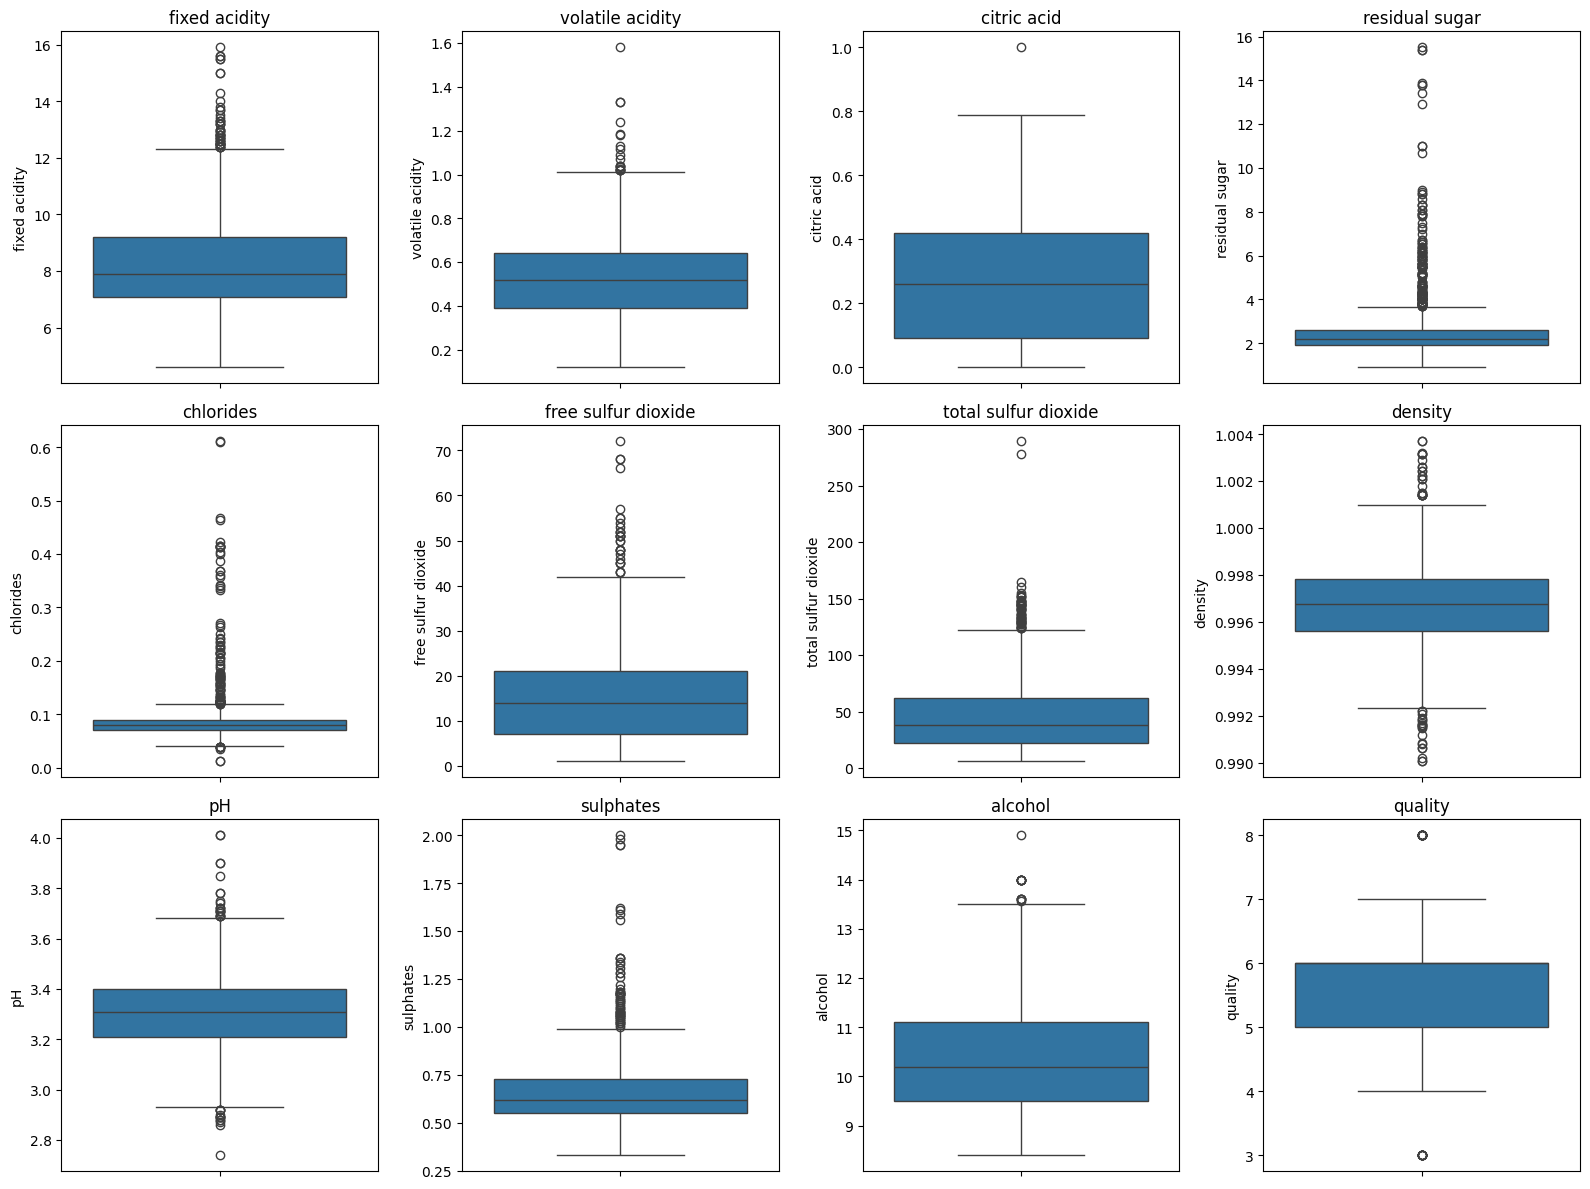

In [27]:
cols = df.columns
n = len(cols)

# grid size
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

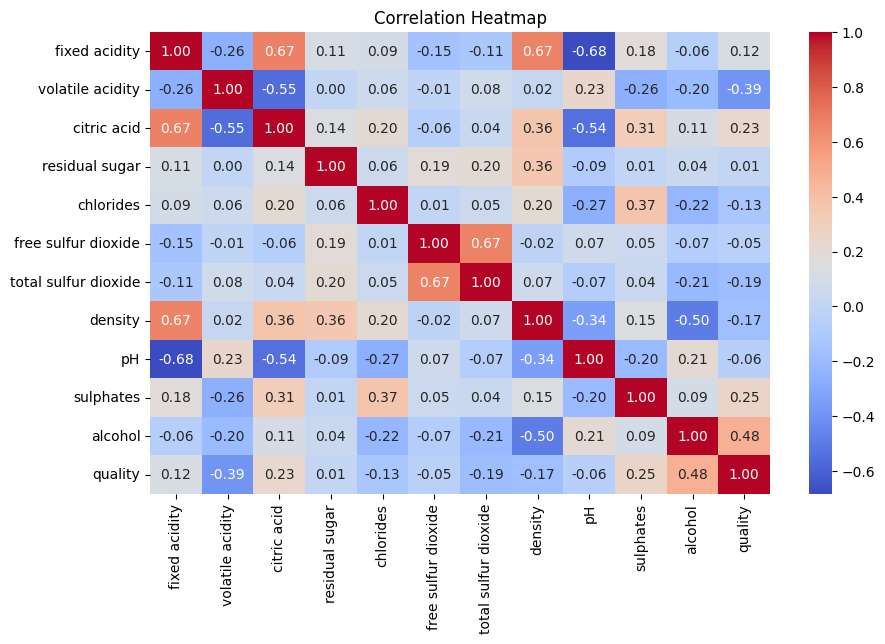

In [28]:
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

<Axes: >

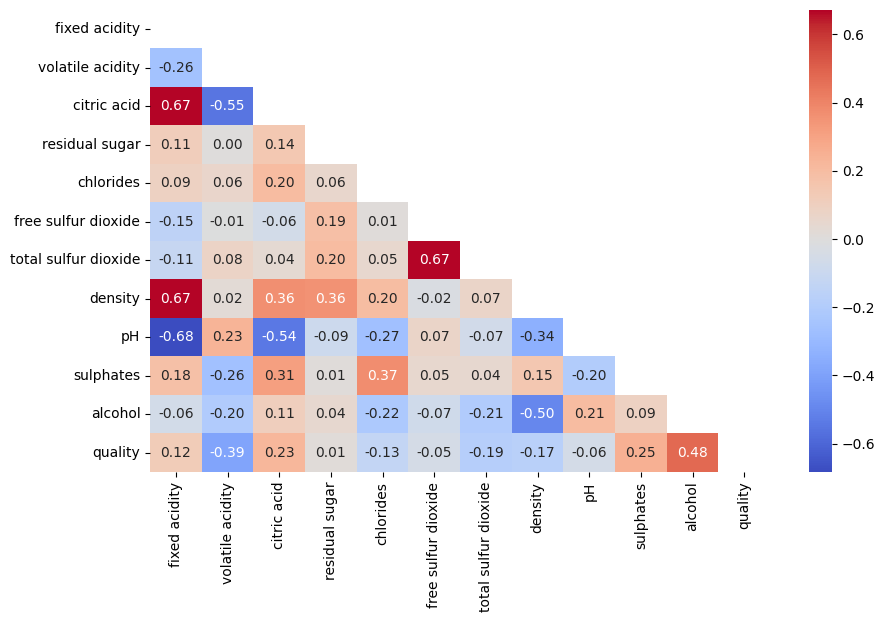

In [29]:

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")

correlation :

for alcohol
strongest positive : alcohol, quality
strongest negative : volatile acidity, quality

others
fixed acidity

vs citric acid ( +ve )
vs density ( +ve )
vs ph ( -ve )

volatile acidity vs citric acid ( -ve )
ph vs citric acid ( -ve )


In [30]:
features_set1 = ['alcohol','density','fixed acidity','pH','citric acid']
# alcohol because it has the highest +ve correlation with quality
# density has strong negative corr with alcohol
# fixed acidity has high +ve corr with density
# pH has Strong -ve correlation with fixed acidity
# citric acid has strong +ve corr with fixed acidity and storng negative corr with pH ,medium +ve with density

features_set2 = ['volatile acidity','citric acid','density','pH']
# I am trying to find the highest correlation chain? va has strong -ve with citric acid(ca) , ca has strong +ve with fixed acidty which has strong corr 
# with density and ph
""" Im thinking like this
snc = strong negative corr , spc = strong positive corr , nc = negative corr , ...
if pH decreases -> fixed acidity increases (snc) -> citric acid increases (spc) -> volatile acidity decreases (snc) -> quality increases (nc)
This implies pH should have snc corr with quality but it doesn't (-0.06) , That is because corr only takes into account pH and quality at a time
pH doesn't directly influence quality , it influences other things which in turn influence quality 
But still indirect relations should also show in the dataset shouldn't they? because its ultimately low pH which led to umm high qulaity 

There are lots of paradox like this , like one thing implies that something should happen other thing implies something else should happen . So what
is supposed to happen? Ig I'll find out when I train a model 

and honestly I only know correlation right now I mean I only know correlation which has the strongest impact on eda , what else can tell me some useful
How can I use math in these

next session me whi chize practice kro jo iss session me use krri h
"""

"""
lets define a relation ~ as strong corr ( +ve/-ve )
Final answer correlation is not transitive , A ~ B and B ~ C . does not imply A ~ C

So my expectation
“indirect relation should show” is not Not necessary

so for now pick some features that 
• have some correlation with target
• are not highly redundant with each other 
"""

'\nlets define a relation ~ as strong corr ( +ve/-ve )\nFinal answer correlation is not transitive , A ~ B and B ~ C . does not imply A ~ C\n\nSo my expectation\n“indirect relation should show” is not Not necessary\n\nso for now pick some features that \n• have some correlation with target\n• are not highly redundant with each other \n'

In [31]:
top10percent = int(df.shape[0]*10/100)
i = np.argsort(df['quality'])
df1 = df.iloc[i[df.shape[0] - top10percent:]]
df1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1125,8.8,0.24,0.35,1.7,0.055,13.0,27.0,0.99394,3.14,0.59,11.3,7
1405,7.7,0.28,0.30,2.0,0.062,18.0,34.0,0.99520,3.28,0.90,11.3,7
259,10.0,0.31,0.47,2.6,0.085,14.0,33.0,0.99965,3.36,0.80,10.5,7
1134,8.5,0.28,0.35,1.7,0.061,6.0,15.0,0.99524,3.30,0.74,11.8,7
1133,7.2,0.48,0.07,5.5,0.089,10.0,18.0,0.99684,3.37,0.68,11.2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1090,10.0,0.26,0.54,1.9,0.083,42.0,74.0,0.99451,2.98,0.63,11.8,8
1120,7.9,0.54,0.34,2.5,0.076,8.0,17.0,0.99235,3.20,0.72,13.1,8
588,5.0,0.42,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.0,8
828,7.8,0.57,0.09,2.3,0.065,34.0,45.0,0.99417,3.46,0.74,12.7,8


In [32]:
df2 = df.iloc[i[:df.shape[0] - top10percent]]

In [33]:
df2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
832,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1147,10.0,0.410,0.45,6.20,0.071,6.0,14.0,0.99702,3.21,0.49,11.8,7
1157,5.1,0.510,0.18,2.10,0.042,16.0,101.0,0.99240,3.46,0.87,12.9,7
1156,8.5,0.180,0.51,1.75,0.071,45.0,88.0,0.99524,3.33,0.76,11.8,7
443,10.0,0.440,0.49,2.70,0.077,11.0,19.0,0.99630,3.23,0.63,11.6,7


In [34]:
df1.agg(['mean','var'])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,8.754717,0.391289,0.370314,2.666981,0.073440,13.880503,34.383648,0.995746,3.288868,0.731195,11.585639,7.113208
var,3.777557,0.018282,0.033749,1.978222,0.000478,108.672339,1275.086060,0.000004,0.024447,0.014850,1.023655,0.101027


In [35]:
df2.agg(['mean','var'])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,8.271597,0.542896,0.260007,2.524653,0.089015,16.095139,47.802083,0.996857,3.313569,0.650083,10.294606,5.472917
var,2.928373,0.031311,0.037224,1.988325,0.002383,109.084410,1043.748502,0.000003,0.023724,0.029622,0.982880,0.445409


what could higher Mean in df1 possibly imply

1. It could mean that high quality wine ( 7, 8) have higher fixed acidity than lower quality mean
2. Mean could be increases due to some values of df1 / subset of values for fixed acidity in df1
3. This is the mean of only top10% values , what about in overall  is the fixed acidity showing some relation , do the high quality wine in df also have high fixed acidity?

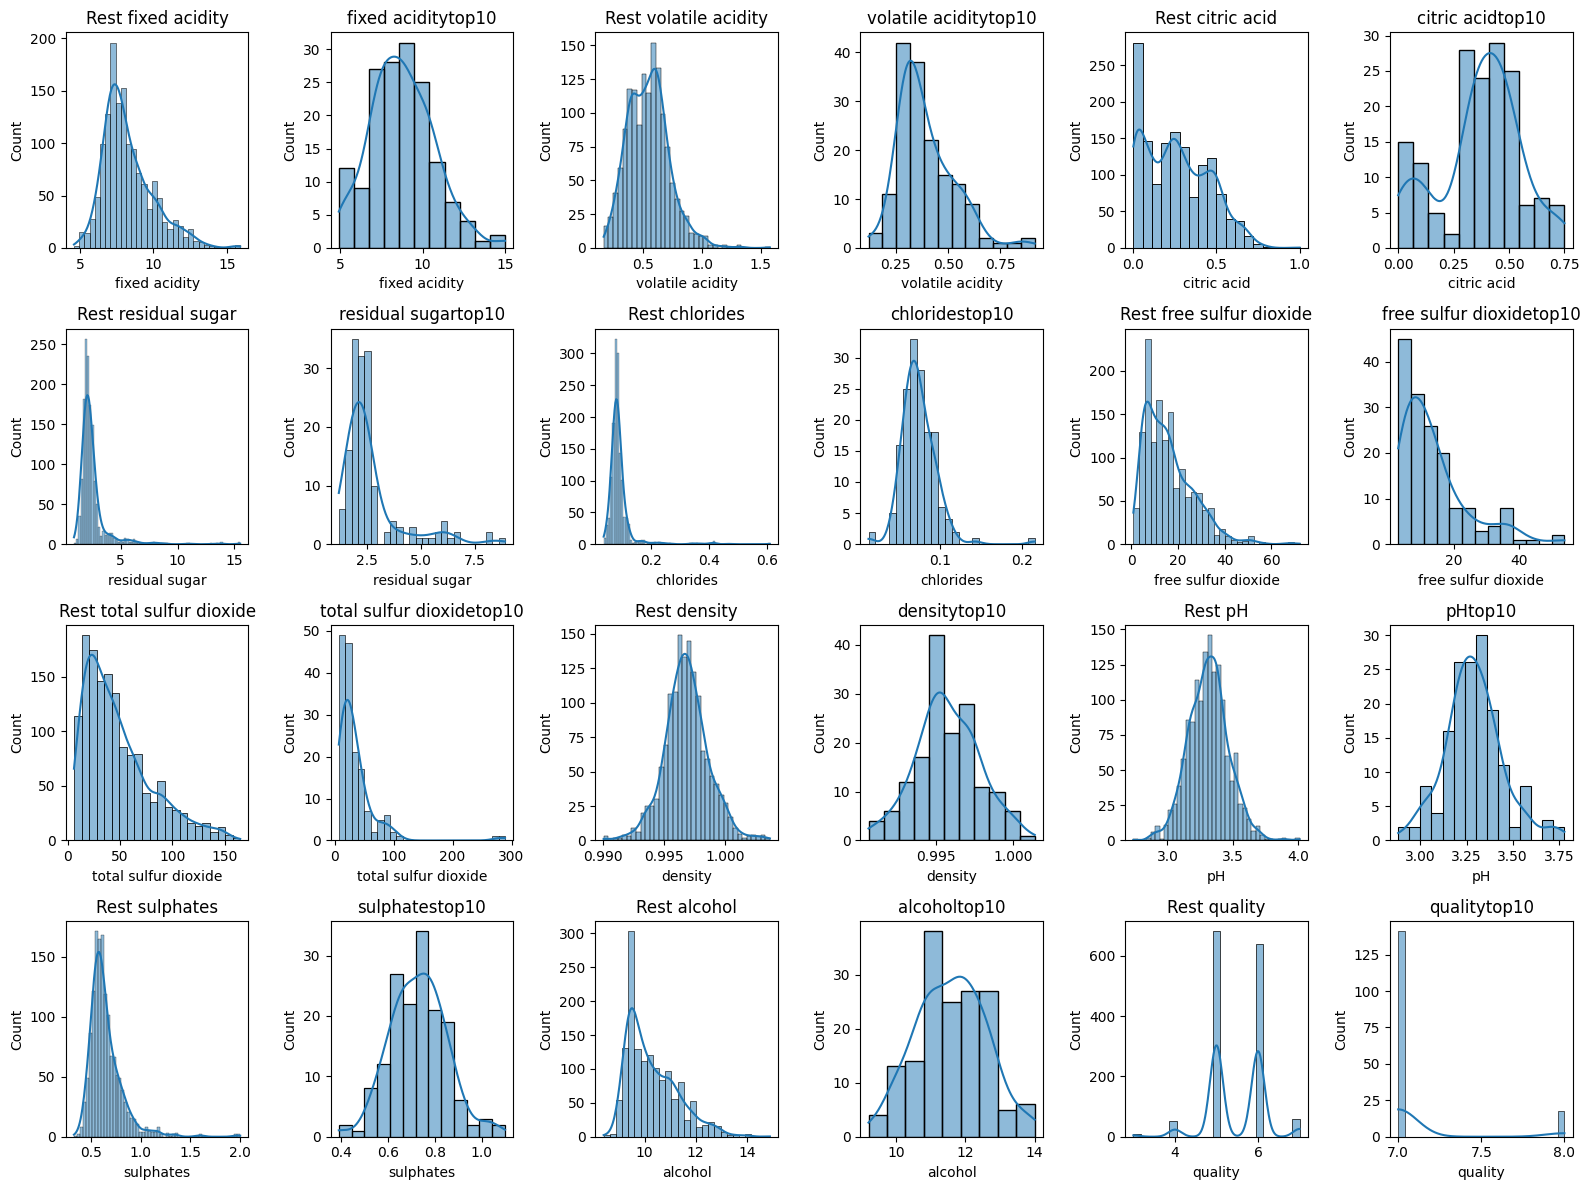

In [36]:
n = len(df.columns)

n_cols = 6
n_rows = 2*int(np.ceil(n/n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(16,3*n_rows))

axes = axes.flatten()

for i,col in zip(np.arange(0,24,2),df.columns):
    sns.histplot(x=df2[col], ax=axes[i],kde=True)
    axes[i].set_title(f"Rest {col}")
    sns.histplot(x=df1[col],ax=axes[i+1],kde=True)
    axes[i+1].set_title(f"{col}top10")

#for j in range(i+1,len(axes)):
#    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

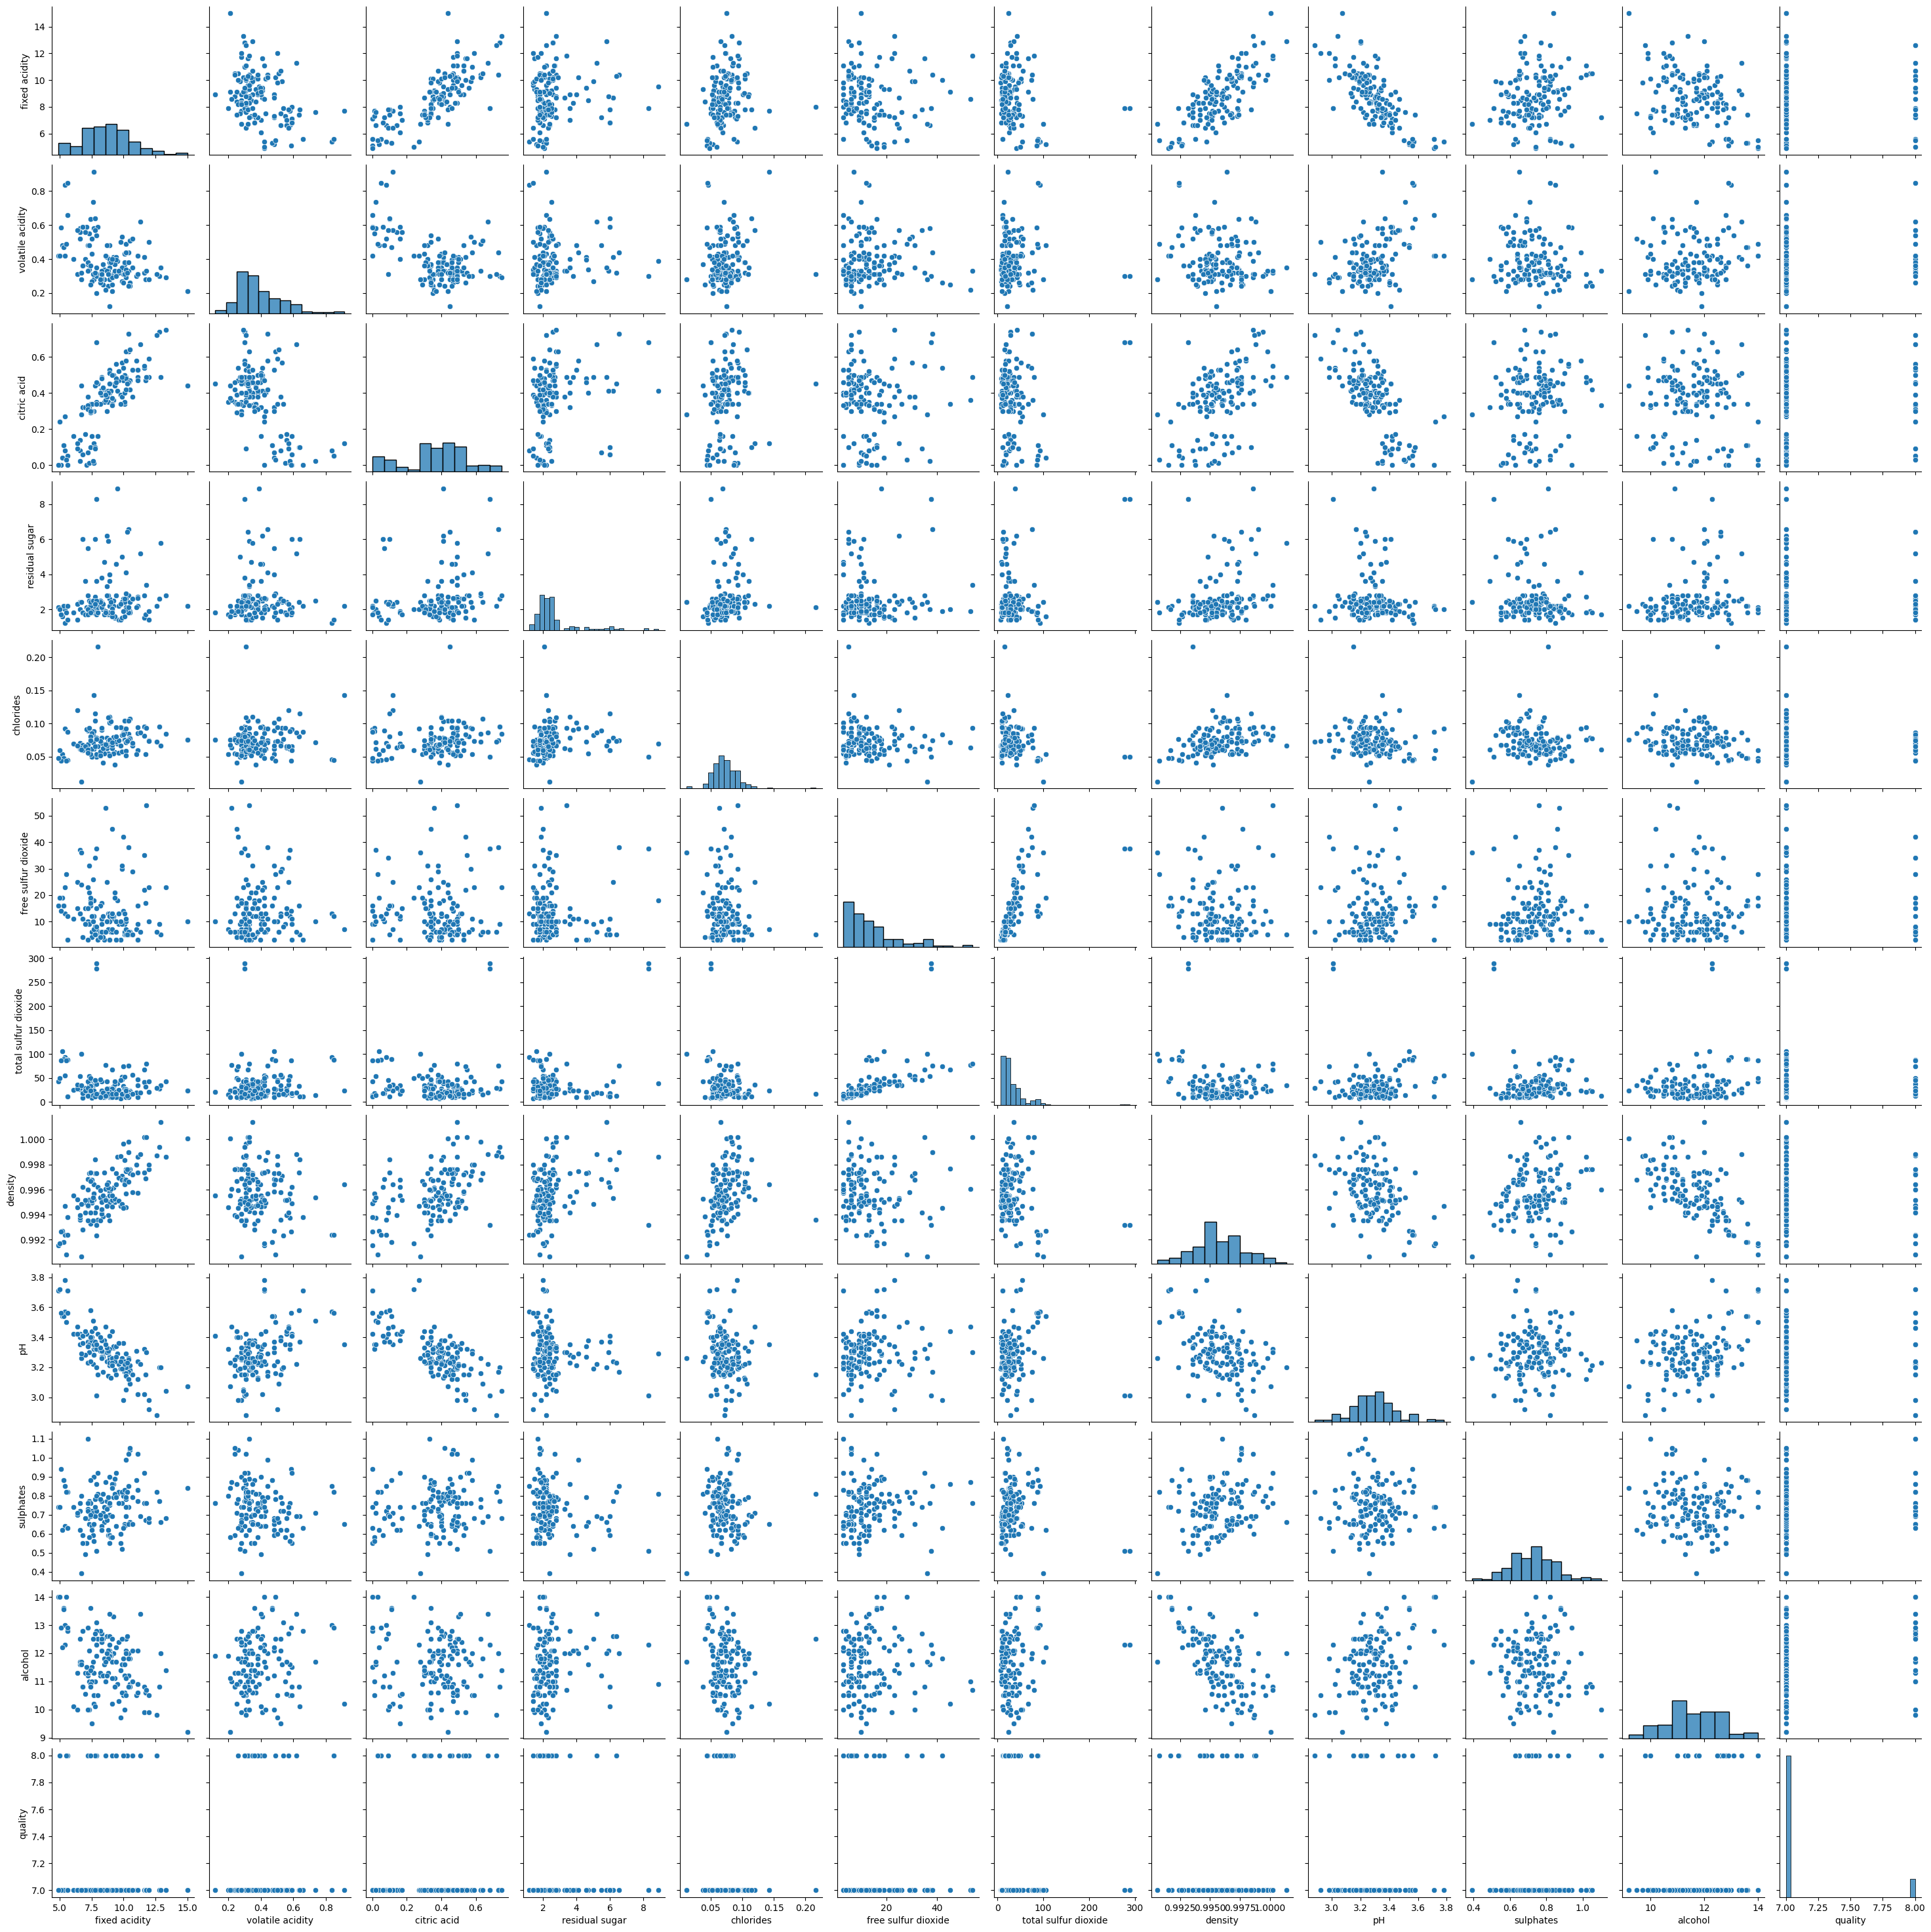

In [37]:
sns.pairplot(df1)

In [38]:
print(np.mean([1,2,10,4,5]))

4.4


In [39]:
help(sns.countplot)

Help on function countplot in module seaborn.categorical:

countplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    stat='count',
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs
)
    Show the counts of observations in each categorical bin using bars.

    A count plot can be thought of as a histogram across a categorical, instead
    of quantitative, variable. The basic API and options are identical to those
    for :func:`barplot`, so you can compare counts across nested variables.

    Note that :func:`histplot` function offers similar functionality with additional
    features (e.g. bar stacking), although its default behavior is somewhat different.

    See the :ref:`tutorial <categorical_tutorial>` for more information.

<Axes: xlabel='quality', ylabel='count'>

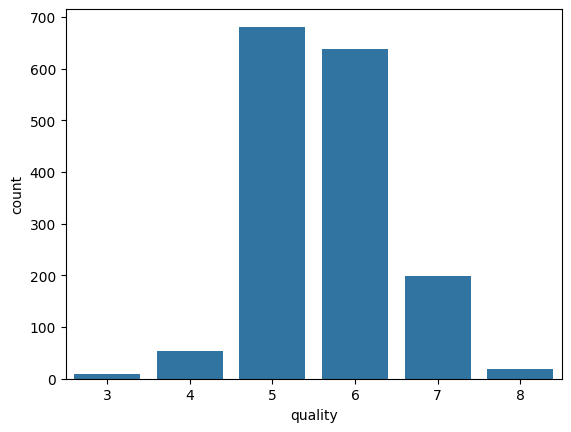

In [40]:
sns.countplot(df,x='quality')
# Conclusion : Most of the wine have 5 or 6 quality

In [41]:
# td stands for temporary dataframe
td = df.groupby('quality')
td.count()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,10,10,10,10,10,10,10,10,10,10,10
4,53,53,53,53,53,53,53,53,53,53,53
5,681,681,681,681,681,681,681,681,681,681,681
6,638,638,638,638,638,638,638,638,638,638,638
7,199,199,199,199,199,199,199,199,199,199,199
8,18,18,18,18,18,18,18,18,18,18,18


In [42]:
td.size()

quality
3     10
4     53
5    681
6    638
7    199
8     18
dtype: int64

([<matplotlib.patches.Wedge at 0x26458ae0c20>,
 [Text(1.0997876992145577, 0.021610568163509154, '3'),
  Text(1.088705509498355, 0.15722694930554137, '4'),
  Text(-0.016208336690042936, 1.0998805798002538, '5'),
  Text(-0.5611913435105995, -0.9460783667163986, '6'),
  Text(0.9848211038954845, -0.4900279515722337, '7'),
  Text(1.0993121986453092, -0.03889331445912539, '8')])

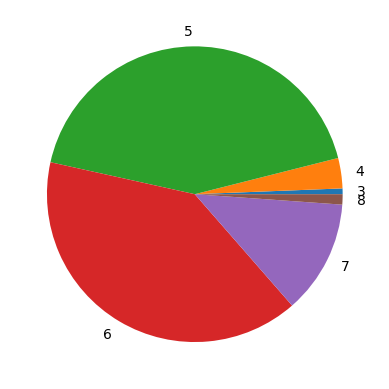

In [43]:
labels = td.size().index
plt.pie(td.size(),
        labels=labels,
        #explode=0.1*np.ones((len(labels)))
        )

# Conclusion : quality 5 and 6 make up most of the dataset followed by 7,4,8,3

In [44]:
df.query('quality==4').info()
# okay the above data is correct

<class 'pandas.DataFrame'>
Index: 53 entries, 18 to 1521
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         53 non-null     float64
 1   volatile acidity      53 non-null     float64
 2   citric acid           53 non-null     float64
 3   residual sugar        53 non-null     float64
 4   chlorides             53 non-null     float64
 5   free sulfur dioxide   53 non-null     float64
 6   total sulfur dioxide  53 non-null     float64
 7   density               53 non-null     float64
 8   pH                    53 non-null     float64
 9   sulphates             53 non-null     float64
 10  alcohol               53 non-null     float64
 11  quality               53 non-null     int64  
dtypes: float64(11), int64(1)
memory usage: 5.4 KB


In [45]:
# Plotting mean per quality
df3 = td.agg(['mean','var'])
df3['alcohol']
#plt.subplot(2)

,mean,var
quality,,
3,9.955000,0.669139
4,10.265094,0.873806
5,9.899706,0.542463
6,10.629519,1.101742
7,11.465913,0.925315
8,12.094444,1.498203


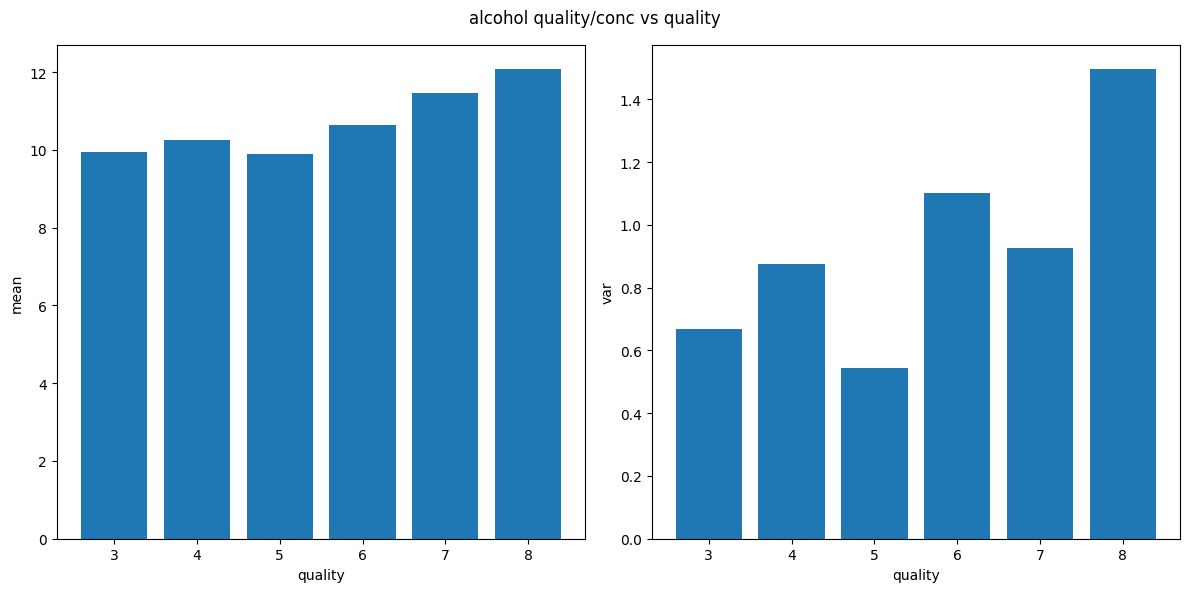

In [46]:
# since mean and var have some relationship ,can we them to make something useful
# mean/var or var/mean ?


fig,axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

for i in range(2):
    axes[i].bar(df3.index,df3['alcohol'].iloc[:,i])
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(df3['alcohol'].columns[i])

fig.suptitle('alcohol quality/conc vs quality')
plt.tight_layout()
plt.show()

# Conclusion : Overall , atleast after quality 5 mean increaeses steadily . the var has like 3 spikes  so its unreliable features

In [47]:
df3['alcohol']['mean']

quality
3     9.955000
4    10.265094
5     9.899706
6    10.629519
7    11.465913
8    12.094444
Name: mean, dtype: float64

In [48]:
df4 = td.agg(['median','std'])

In [49]:
df5 = pd.DataFrame({
"mean/median" : df3['alcohol']['mean'] /df4['alcohol']['median'] ,
"var/std" : df3['alcohol']['var'] /df4['alcohol']['std']
})

In [50]:
df5

,mean/median,var/std
quality,,
3,1.003023,0.818009
4,1.026509,0.934776
5,1.020588,0.736521
6,1.012335,1.049639
7,0.997036,0.961933
8,0.995428,1.224011


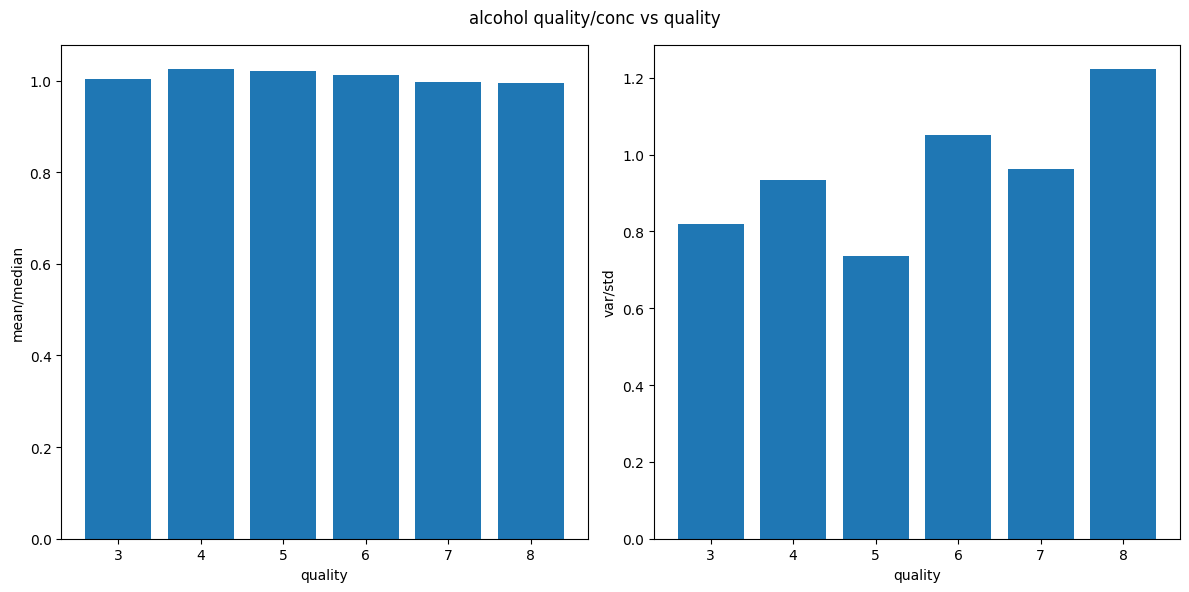

In [51]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

for i in range(2):
    axes[i].bar(df5.index,df5.iloc[:,i])
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(df5.columns[i])

fig.suptitle('alcohol quality/conc vs quality')
plt.tight_layout()
plt.show()

# conclusion :
# I see that from quality 4 onwards the mean/median steadily decrease , altho it decrease only by a little
# like at 4 its above 1 but after that it slow decrease to a bit below 1 by quality 8

# I see 3 spikes in var/std so not reliable 

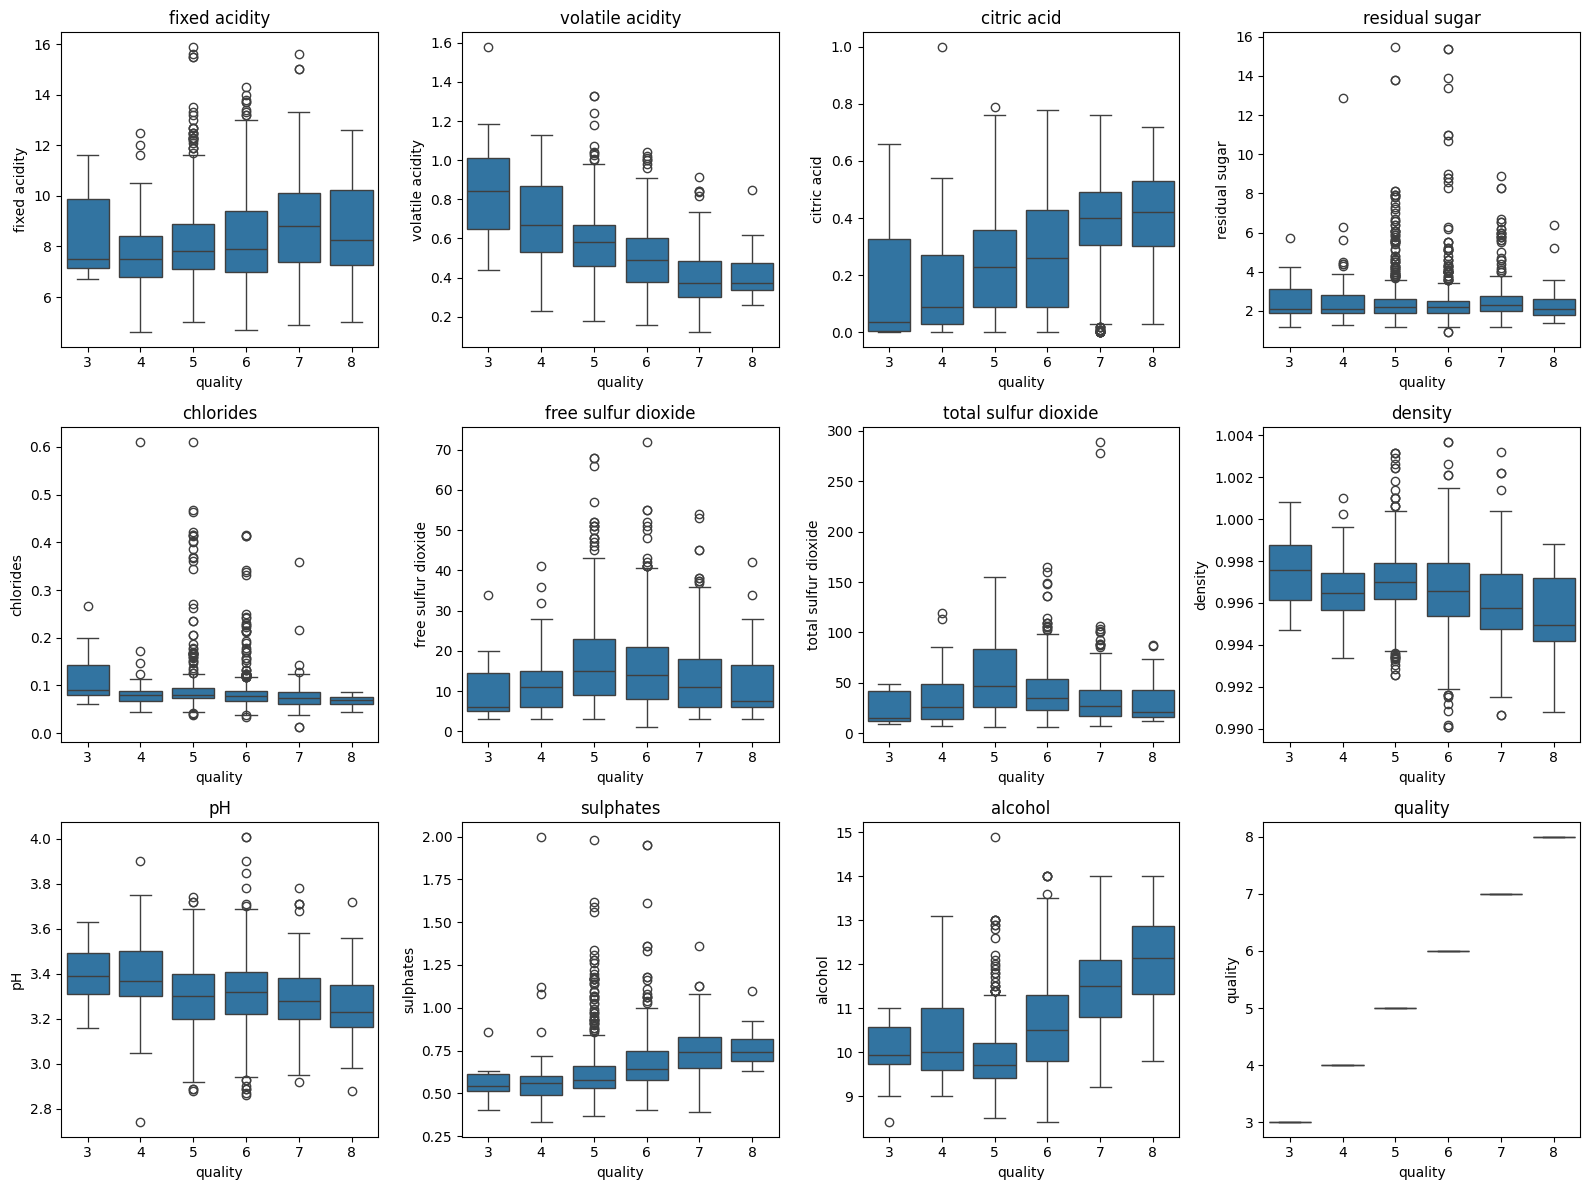

In [52]:
# As quality increases, this feature ______”
cols = df.columns
n = len(cols)

# grid size
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df['quality'], y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [53]:
df3.head()

fixed acidity           volatile acidity           citric acid  \
                 mean       var             mean       var        mean   
quality                                                                  
3            8.360000  3.136000         0.884500  0.109730    0.171000   
4            7.779245  2.645907         0.693962  0.048448    0.174151   
5            8.167254  2.446058         0.577041  0.027159    0.243686   
6            8.347179  3.232260         0.497484  0.025909    0.273824   
7            8.872362  3.969990         0.403920  0.021090    0.375176   

                  residual sugar           chlorides            ...  \
              var           mean       var      mean       var  ...   
quality                                                         ...   
3        0.062832       2.635000  1.964472  0.122500  0.004388  ...   
4        0.040413       2.694340  3.202083  0.090679  0.005805  ...   
5        0.032401       2.528855  1.848927  0.092736  0.002884  ...   
6        0.038067       2.477194  2.078141  0.084956  0.001565  ...   
7        0.037804       2.720603  1.881038  0.076588  0.000868  ...   

        total sulfur dioxide                density                  pH  \
                        mean          var      mean       var      mean   
quality                                                                   
3                  24.900000   283.211111  0.997464  0.000004  3.398000   
4                  36.245283   760.842525  0.996542  0.000002  3.381509   
5                  56.513950  1368.490614  0.997104  0.000003  3.304949   
6                  40.869906   626.913975  0.996615  0.000004  3.318072   
7                  35.020101  1101.656160  0.996104  0.000005  3.290754   

                  sulphates              alcohol            
              var      mean       var       mean       var  
quality                                                     
3        0.020751  0.570000  0.014889   9.955000  0.669139  
4        0.032921  0.596415  0.057308  10.265094  0.873806  
5        0.022686  0.620969  0.029262   9.899706  0.542463  
6        0.023714  0.675329  0.025170  10.629519  1.101742  
7        0.022530  0.741256  0.018398  11.465913  0.925315  

[5 rows x 22 columns]

In [54]:
df6 = pd.DataFrame({
"mean/median" : df3['sulphates']['mean'] /df4['sulphates']['median'] ,
"var/std" : df3['sulphates']['var'] /df4['sulphates']['std']
})

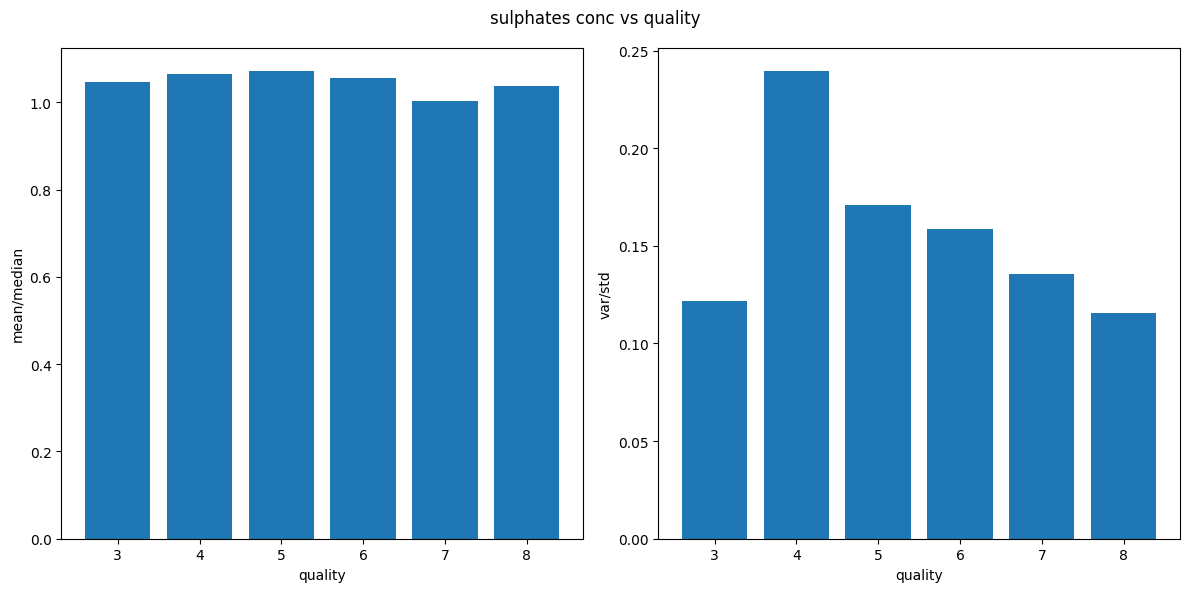

In [55]:
# Just plotting this to see how outliers are affecting the mean/median graph
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

for i in range(2):
    axes[i].bar(df6.index,df6.iloc[:,i])
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(df6.columns[i])

fig.suptitle('sulphates conc vs quality')
plt.tight_layout()
plt.show()


In [56]:
"""
Boxplot distribution trends ( full data )
fixed acidity : no consistent behavior to report
volatile acidity : distribution(Q3 - Q1),median consistently decreases till 7 , on 8 median almost stay stable and distribution kinda umm s
shrinks
citric acid : Median consistently increase , and distribution also almost consistently increases
residual sugar : Nothing to determine , so many outliers , median is also not showing consistent behavior
chlorides : meadian steadily decrease after quality 5 , damn so many outliers
free sulphur dioxide : steady decrease in median after quality 5
total sulphur dioxide : steady decrease in median after quality 5
density : Median increase till 3-7 then decrease
pH : increase decrease nothing to say ( not a linear relation but it does decrease , like 
inclined sinosodial relation )
sulphates : median steadily increase then stable after quality 4
alcohol : after quality 4 , the median and the distribution strictly increase ( most stable increase seen yet )
"""

'\nBoxplot distribution trends ( full data )\nfixed acidity : no consistent behavior to report\nvolatile acidity : distribution(Q3 - Q1),median consistently decreases till 7 , on 8 median almost stay stable and distribution kinda umm s\nshrinks\ncitric acid : Median consistently increase , and distribution also almost consistently increases\nresidual sugar : Nothing to determine , so many outliers , median is also not showing consistent behavior\nchlorides : meadian steadily decrease after quality 5 , damn so many outliers\nfree sulphur dioxide : steady decrease in median after quality 5\ntotal sulphur dioxide : steady decrease in median after quality 5\ndensity : Median increase till 3-7 then decrease\npH : increase decrease nothing to say ( not a linear relation but it does decrease , like \ninclined sinosodial relation )\nsulphates : median steadily increase then stable after quality 4\nalcohol : after quality 4 , the median and the distribution strictly increase ( most stable incre

In [57]:
# I use this rule , I plot various plots for a feature , if i see a trend then I pick that feature
#  Alcohol Barplots summary
# As alcohol increases quality tends to increases ( as shown in mean vs quality )
# Alcohol varies a lot within each quality level , no trend here ( var vs quality )
# mean ≈ median , mean and median are very close no strong skewness which
#  means alcohol values are not heavily distorted by outliers 
# - no extreme values pulling mean
# Alcohol is a stable features

In [58]:
# COPY PASTED
# top 10% by quality
n_top = max(1, int(0.10 * len(df)))
df_sorted = df.sort_values("quality", ascending=False)

top = df_sorted.head(n_top)
rest = df_sorted.iloc[n_top:]

num_cols = [c for c in df.columns if c != "quality"]

summary = pd.DataFrame({
    "top_mean": top[num_cols].mean(),
    "rest_mean": rest[num_cols].mean(),
    "top_var": top[num_cols].var(),
    "rest_var": rest[num_cols].var(),
    "top_median": top[num_cols].median(),
    "rest_median": rest[num_cols].median(),
})

summary["mean_diff"] = summary["top_mean"] - summary["rest_mean"]
summary["var_diff"] = summary["top_var"] - summary["rest_var"]
summary.sort_values("mean_diff", ascending=False)

,top_mean,rest_mean,top_var,rest_var,top_median,rest_median,mean_diff,var_diff
alcohol,11.627463,10.289988,0.977771,0.975770,11.70000,10.0000,1.337475,2.000751e-03
fixed acidity,8.676730,8.280208,3.312936,2.986967,8.70000,7.8500,0.396521,3.259688e-01
residual sugar,2.698113,2.521215,2.060123,1.978234,2.20000,2.2000,0.176898,8.188855e-02
citric acid,0.367987,0.260264,0.033560,0.037301,0.39000,0.2400,0.107724,-3.740353e-03
sulphates,0.728553,0.650375,0.015888,0.029555,0.73000,0.6100,0.078178,-1.366629e-02
density,0.995701,0.996862,0.000004,0.000003,0.99552,0.9968,-0.001161,8.374044e-07
chlorides,0.073434,0.089016,0.000478,0.002383,0.07100,0.0800,-0.015582,-1.904941e-03
pH,3.287107,3.313764,0.024593,0.023698,3.27000,3.3100,-0.026657,8.949974e-04
volatile acidity,0.395629,0.542417,0.018152,0.031468,0.36000,0.5400,-0.146788,-1.331653e-02
free sulfur dioxide,13.911950,16.091667,115.697894,108.328284,11.00000,14.0000,-2.179717,7.369611e+00


Good. This is the right confusion. Let’s make it mechanical so you don’t guess.

---

### What I’m actually looking at (in order)

For each feature:

#### 1. **Mean difference (MAIN thing)**

Ask:

👉 Is it **clearly bigger than others?**

Rough guide (from your data):

• **> 0.5** → very strong (alcohol ✅)
• **0.1 – 0.5** → moderate (citric acid, volatile acidity ✅)
• **< 0.05** → weak ❌

Sign:
• +ve → increases with quality
• -ve → decreases with quality

---

#### 2. **Median (confirmation)**

👉 Does median move in same direction as mean?

If yes → good signal
If no → suspicious

---

#### 3. **Variance (just a check)**

👉 Is variance extremely large or unstable?

• similar → fine
• much larger → noisy
• much smaller → stable

---

### Now let’s apply this to YOUR table

#### Alcohol

mean_diff = **+1.33** → HUGE
median also ↑
variance same

👉 Strong +ve feature ✅

---

#### Volatile acidity

mean_diff = **-0.146** → clear
median ↓
variance lower

👉 Strong -ve feature ✅

---

#### Citric acid

mean_diff = **+0.10** → decent
median ↑

👉 Moderate +ve feature ✅

---

#### Sulphates

mean_diff = **+0.078** → small but noticeable

👉 Weak–moderate ⚠️

---

#### Residual sugar

mean_diff = **+0.17??** but median SAME

👉 misleading → drop ❌

---

#### Density

mean_diff ≈ **0**

👉 useless ❌

---

#### pH

mean_diff ≈ **0.02**

👉 useless ❌

---

#### Chlorides

small change

👉 weak ❌

---

#### Sulfur dioxide

big diff BUT huge variance

👉 noisy ⚠️

---

### So the REAL rule is:

👉 Don’t just see “change”
👉 Compare **relative size of change across features**

---

### Final mental shortcut

For each column, ask:

1. Is mean_diff **clearly noticeable compared to others?**
2. Does median agree?
3. Is variance not crazy?

If YES → keep
If NO → drop

---

You were missing **how to judge “how much change”**.

Now you have a scale 👍


In [59]:
# for histograms just ask 
# “Does top 10% behave differently from the rest?”

""" Which features had the most shift in values in the top 10 
Volatile acidity
citric acid
residual sugar 
density
pH maybe
alcohol
"""

' Which features had the most shift in values in the top 10 \nVolatile acidity\ncitric acid\nresidual sugar \ndensity\npH maybe\nalcohol\n'

# Training Models

**Regression**

* Linear Regression
* Ridge Regression
* Lasso Regression
* Elastic Net
* Support Vector Regression (SVR)
* Decision Tree (regression)
* Random Forest (regression)
* Gradient Boosting (regression)

**Classification**

* K-Nearest Neighbors (KNN)
* Random Forest (classification)
* Naive Bayes (Gaussian, Multinomial, Bernoulli)
* Support Vector Machine (SVM)
* Decision Tree (classification)
* Gradient Boosting (XGBoost, LightGBM, CatBoost)
* Logistic Regression

**Clustering**

* K-Means
* Hierarchical Clustering
* DBSCAN
* Gaussian Mixture Models (GMM)

**Dimensionality Reduction**

* PCA
* t-SNE
* UMAP

**Anomaly Detection**

* Isolation Forest
* One-Class SVM
* Local Outlier Factor (LOF)

**Ensemble (concepts)**

* Bagging
* Boosting
* Stacking

## KNN

In [60]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [61]:
# I,ll use KNN first
features = ['volatile acidity', 'citric acid','residual sugar','density','pH','alcohol']
target = 'quality'

X = df[features]
y= df[target]

<Axes: >

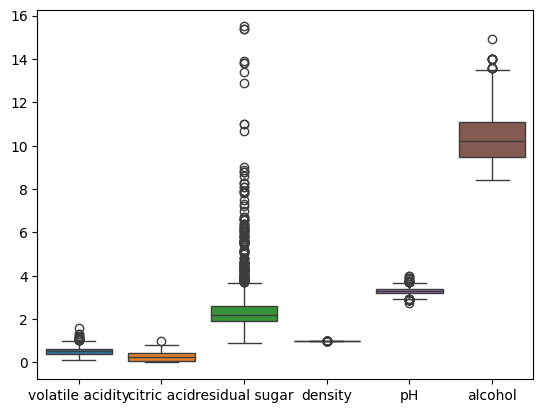

In [62]:
sns.boxplot(df[features])


In [64]:
# Lets try removing outliers
z_scores = np.abs(zscore(X,axis=0))
outlier_mask = np.all(z_scores > 1, axis=1)

X_clean = X[~outlier_mask]
y_clean = y[~outlier_mask]

In [65]:
outlier_mask

array([False, False, False, ..., False, False, False], shape=(1599,))

In [66]:
# Lets try using dimensionality reduction with PCA
X_train,X_test,y_train,y_test = train_test_split(X_clean,y_clean,test_size=0.2)

pca = PCA(n_components=0.95) # keep 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)


In [67]:
# Lets Try changing all sorts of parameters and see if it changes accuracy

In [68]:
#scaler = RobustScaler() #scales outliers to reduce their impact
#X_Scaled = scaler

In [69]:
# Commenting this for pca for now
# X_train, X_test, y_train, y_test = train_test_split(X_clean,y, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5,
                           weights='distance',
                           metric='euclidean')

knn.fit(X_train_pca, y_train)

predictions = knn.predict(X_test_pca)

accuracy = accuracy_score(y_test, predictions)
print('Accuracy :',accuracy)


Accuracy : 0.56875


##### Actually I think that recording this a bit useless cause har baar run karne me different reseult aa rha h
1. Accuracy : 0.5875   [ with my first shortlisted(fs) features ]
2. Accuracy : 0.596875 [ with all features in train ]
3. Accuracy : 0.55     [ with residual sugar removed from (fs) ]
4. Accurady : 0.60+    [ this suddenly when I added weights='distance']
5. Accuracy : 0.60+    [ but higher changes of getting higher values 0.65 than the above accuracy ]

6. Accuracy : 50-69?   [ when I remove outliers ]
7. Accuracy : 30-60    [ when I use pca with n_components=5 ]
8. Accuracy : 40-60    [ when pca n_components=0.95 ] 

In [70]:
"""
Do This next 

Fix random state in train_test_split
Try different K values: for k in range(1,20)
Use cross_validation , instead of one accuracy , get average accuracy over multiple splits 
"""

'\nDo This next \n\nFix random state in train_test_split\nTry different K values: for k in range(1,20)\nUse cross_validation , instead of one accuracy , get average accuracy over multiple splits \n'

In [71]:
from itertools import product

In [72]:
judge = np.array(list(product([True,False],repeat=3)))
judge

array([[ True,  True,  True],
       [ True,  True, False],
       [ True, False,  True],
       [ True, False, False],
       [False,  True,  True],
       [False,  True, False],
       [False, False,  True],
       [False, False, False]])

In [73]:
td = pd.DataFrame({'RobustScaler':judge[:,0],'Z_score':judge[:,1],'Pca':judge[0:,2]})
td['accuracy'] = np.nan

In [74]:
# Not using two types of scaling at once , it has no affect
td = td.drop([0,1])
td

,RobustScaler,Z_score,Pca,accuracy
2,True,False,True,NaN
3,True,False,False,NaN
4,False,True,True,NaN
5,False,True,False,NaN
6,False,False,True,NaN
7,False,False,False,NaN


In [95]:
features = ['volatile acidity', 'citric acid','residual sugar','density','pH','alcohol']
target = 'quality'

X = df[features]
y= df[target]

In [76]:
td.head(3)

,RobustScaler,Z_score,Pca,accuracy
2,True,False,True,NaN
3,True,False,False,NaN
4,False,True,True,NaN


In [77]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

for i in range(6):
    if td.iloc[i,0]:
        scaler = RobustScaler()
        X_new = scaler.fit_transform(X_train)
        #y_new = scaler.fit_transform(y_train)
    if td.iloc[i,1]:
        z_scores = np.abs(zscore(X,axis=0))
        outlier_mask = np.all(z_scores > 3 , axis = 1)
        X_new = z_scores[~outlier_mask]
        y_train = y[~outlier_mask]

    if td.iloc[i,2]:
        pca = PCA(n_components=0.95) 
        X_new = pca.fit_transform(X_new)
        X_test_new = pca.transform(X_test)
    
    
    knn = KNeighborsClassifier()
    knn.fit(X_new,y_train)
    predictions = knn.predict(X_test_new)
    X_test_new = X_test
    accuracy = accuracy_score(y_test, predictions)
    td.iloc[i,3]= accuracy

c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
c:\Users\fb

In [78]:
td

,RobustScaler,Z_score,Pca,accuracy
2,True,False,True,0.418750
3,True,False,False,0.412500
4,False,True,True,0.409375
5,False,True,False,0.409375
6,False,False,True,0.409375
7,False,False,False,0.306250


We'll use RobustScaler with pca going forward

In [114]:
L = []
td2 = pd.DataFrame(columns=["k","accuracy_score"])
X = df[features]
y= df[target]

X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_train)
pca = PCA(n_components=0.95)
X_scaled = pca.fit_transform(X_scaled)
X_test = pca.transform(X_test)

for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled,y_train)
    predictions = knn.predict(X_test)
    accuracy  = accuracy_score(y_test,predictions)
    L.append([k,accuracy])

td2 = pd.DataFrame(L,columns=["k","accuracy"],index=None)
td2

c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


,k,accuracy
0,1,0.409375
1,2,0.409375
2,3,0.378125
3,4,0.412500
4,5,0.418750
5,6,0.415625
6,7,0.390625
7,8,0.400000
8,9,0.418750
9,10,0.415625


In [94]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

param_grid = [
    {'scaler': [StandardScaler(),MinMaxScaler()],
     'knn__n_neighbors':list(range(1,31)),
     'knn__weights':['uniform','distance'],
     'knn__metric':['euclidean','manhattan','minkowski'],
     'knn__p':[1,2],
     'knn__algorithm':['auto','ball_tree','kd_tree','brute'],
     'knn__leaf_size':[10,20,30,40]}
]

grid = GridSearchCV(pipe,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    verbose=1
                    )

grid.fit(X_train, y_train)

print("Best Params:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

print("Test accuracy:", grid.score(X_test,y_test))

Fitting 5 folds for each of 11520 candidates, totalling 57600 fits
Best Params: {'knn__algorithm': 'auto', 'knn__leaf_size': 10, 'knn__metric': 'manhattan', 'knn__n_neighbors': 23, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': StandardScaler()}
Best CV Score: 0.9014767156862746
Test accuracy: 0.89375


In [96]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=23,
                           algorithm='auto',
                           leaf_size=10,
                           metric='manhattan',
                           p=1,
                           weights='distance',
                           )
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       273
           1       0.70      0.49      0.57        47

    accuracy                           0.89       320
   macro avg       0.81      0.73      0.76       320
weighted avg       0.88      0.89      0.89       320



In [97]:
print(confusion_matrix(y_test,y_pred))

[[263  10]
 [ 24  23]]


```
Best Params: {'knn__algorithm': 'auto',
              'knn__leaf_size': 10,
              'knn__metric': 'euclidean',
              'knn__n_neighbors': 16,
              'knn__p': 1,
              'knn__weights': 'distance',
              'scaler': MinMaxScaler()}

Best CV Score: 0.6536580882352941
Test accuracy: 0.6625
```

## Naive Bayes


In [108]:
features = ['volatile acidity', 'citric acid','residual sugar','density','pH','alcohol']
target = 'quality'

X = df[features]
y= df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

In [59]:
# with Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
model = GaussianNB()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy : 0.484375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.20      0.22        10
           5       0.55      0.79      0.65       130
           6       0.42      0.27      0.33       132
           7       0.35      0.36      0.35        42
           8       0.00      0.00      0.00         5

    accuracy                           0.48       320
   macro avg       0.26      0.27      0.26       320
weighted avg       0.45      0.48      0.45       320



c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fbase\All_vscode_projects\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [ ]:
def label_quality(x):
    if x<=5:
        return 0 # low
    elif x==6:
        return 1 # medium
    else:
        return 2 # high
    


In [ ]:
df['quality_label'] = df['quality'].apply(label_quality)

In [99]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [109]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

In [77]:
# with Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [91]:
model = GaussianNB()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy : 0.853125
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       273
           1       0.50      0.79      0.61        47

    accuracy                           0.85       320
   macro avg       0.73      0.83      0.76       320
weighted avg       0.89      0.85      0.87       320



In [93]:
print(confusion_matrix(y_test, y_pred))

[[236  37]
 [ 10  37]]


Naive Bayes (class 1)
Precision = 0.50
Recall = 0.79

👉 Interpretation:

Finds most positives (high recall) ✅
But many false alarms (low precision) ❌
KNN (class 1)
Precision = 0.70
Recall = 0.49

👉 Interpretation:

More reliable when it says “positive” ✅
But misses many positives ❌


🔹 Final comparison (this is the real takeaway)

Naive Bayes

👉 Better at finding positives (high recall)

KNN

👉 Better at being correct when predicting positives (high precision)


Precision → “When I say positive, am I correct?”

Recall → “Am I finding most of the actual positives?”

1. “Which handles imbalance better?”

Your dataset:

Many wines <7
Few wines ≥7

👉 That’s imbalance

Now think:

Naive Bayes
Uses probabilities
Gets influenced by class frequency

👉 Tends to favor majority class

KNN
Looks at nearby points

👉 If neighbors are mostly majority → prediction = majority

Logistic Regression
Learns a boundary

👉 Can handle imbalance a bit better, but still biased

Random Forest
Many trees, different splits

👉 Usually handles imbalance better than others

So what you should check

👉 Which model gives:

Higher recall for class 1 (≥7)

That model is handling imbalance better.

2. “Which handles non-linearity better?”

This just means:

👉 Can the model capture complex patterns, not just straight-line separation

Logistic Regression
Draws a straight line (or plane)

👉 Weak for complex patterns ❌

Naive Bayes
Very simplified assumptions

👉 Also weak ❌

KNN
No assumptions
Looks locally

👉 Can handle complex shapes ✅

Decision Tree / Random Forest
Split data in many ways

👉 Very good at non-linear patterns ✅

## Random Forest

In [104]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)

In [105]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       273
           1       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



conclusion : 
1. More complex model != always better
2. Data quality > model choice
3. Imbalance effects all models

## Logistic Regression

In [111]:
model = LogisticRegression(max_iter = 1000,class_weight='balanced')
model.fit(X_train,y_train)

y_pred_lr = model.predict(X_test)

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       273
           1       0.42      0.87      0.57        47

    accuracy                           0.80       320
   macro avg       0.70      0.83      0.72       320
weighted avg       0.89      0.80      0.83       320





## Conclusion

At first, I was trying to predict the exact wine quality (3–8), but that turned out to be messy and unreliable.
So I switched to a simpler problem:
-> predicting whether a wine is good (≥7) or not.

---

### Model behavior

Naive Bayes

* Catches most of the good wines (high recall)
* But also makes a lot of wrong positive predictions (low precision)

KNN

* More accurate when it predicts a wine as good (higher precision)
* But misses a lot of actual good wines (low recall)

Logistic Regression

* Doesn’t perform well because it assumes a simple (linear) boundary
* Using `class_weight='balanced'` improves recall, but reduces precision

Random Forest

* More balanced overall
* But doesn’t improve much compared to others

---

### Insights

* The dataset is imbalanced (very few high-quality wines)
* The features for different classes overlap a lot

Because of this, even better models don’t improve performance much

---

Model choice matters, but data matters more

* If we want to catch as many good wines as possible → Naive Bayes
* If we want fewer false positives → KNN / Logistic Regression
* If we want a balance → Random Forest

---
